# 06 — ScanTailor + MRC engine lab

Interactive companion to the `scantailor_mrc` pipeline engine (the production default
since 2026-06-07). Runs one cached book through the new steps and renders the result
next to the raw scans — use it to eyeball quality before launching a batch (notebook 05)
and to tune `configs/pipeline.toml`.

The engine (prototyped 2026-06-07 on the fad sample):

1. **Split** — spreads cut at the gutter by our `imaging.analyze_spread`
   (`scantailor-deviant-cli` batch mode mis-propagates its own split, see
   `pipeline/steps/scantailor.py`)
2. **ScanTailor** — content detection (kills facing-page slivers + binding shadows),
   deskew, illumination normalization, dewarp, uniform page size with real margins
3. **DocRes** *(optional, `[docres] enabled`)* — AI appearance pass that keeps tones
   (stamps, photos); pair with `color_mode = "color_grayscale"`
4. **MRC** — Tesseract hOCR + `recode_pdf`: JBIG2 text mask over JPEG2000 layers.
   fad sample: **10.1 MB (legacy) → 1.8 MB**, more OCR words extracted

Requirements: `scantailor-deviant-cli` on `PATH` (`~/.local/bin` build or the Docker
image), Tesseract with `slk`/`ces`, `jbig2` (brew/`Dockerfile`).

In [1]:
%load_ext autoreload
%autoreload 2

import shutil
import tomllib
from pathlib import Path

import matplotlib.pyplot as plt
import pypdfium2 as pdfium

from evilflowers_books_digitalizer import LocalCache, load_settings
from evilflowers_books_digitalizer.pipeline.base import BookContext, Pipeline
from evilflowers_books_digitalizer.pipeline.factory import DEFAULT_CONFIG_PATH
from evilflowers_books_digitalizer.pipeline.steps import (
    DetectLanguage,
    DocResEnhance,
    EnrichPdfMetadata,
    MrcPdf,
    ScanTailorScans,
)

settings = load_settings()
cache = LocalCache(settings.cache_dir)
config = tomllib.load(DEFAULT_CONFIG_PATH.open("rb"))
config

{'pipeline': {'engine': 'scantailor_mrc'},
 'scantailor': {'binary': 'scantailor-deviant-cli',
  'color_mode': 'mixed',
  'margins_mm': 8.0,
  'dewarping': 'auto',
  'normalize_illumination': True,
  'despeckle': 'cautious',
  'dpi': 300},
 'docres': {'enabled': False,
  'repo': '~/.local/share/evilflowers-tools/DocRes',
  'python': '~/.local/share/evilflowers-tools/venv-docres/bin/python',
  'task': 'appearance'},
 'mrc': {'mask_compression': 'jbig2', 'jpeg2000_encoder': 'pillow'},
 'ocr': {'language': 'auto'},
 'preprocess': {'split': True,
  'deskew': True,
  'whiten': True,
  'color_mode': 'keep'},
 'legacy_ocr': {'output_type': 'pdfa-2', 'optimize': 2, 'rotate_pages': True}}

## Pick a locally cached book

Anything under `.cache/scans/<source>/<book_id>/` works (download via notebook 02 if
empty — needs the VPN).

In [2]:
cached = sorted(
    (p.parent.name, p.name, len(list(p.glob("*.tif*"))))
    for p in (settings.cache_dir / "scans").glob("*/*")
    if p.is_dir() and any(p.glob("*.tif*"))
)
for source, book_id, n in cached:
    print(f"{source}/{book_id}  ({n} frames)")

SOURCE, BOOK_ID, _ = cached[0]  # <- pick yours

fad/CVI_OPACID_FA_STAVEBNO_EKOLOGICKA)KVALITA_BUDOV  (21 frames)
fei/FEI_9788080707484  (2 frames)
mtf/CVI_OPACID_MTF_8022714887  (2 frames)
mtf/CVI_OPACID_MTF_8022716863  (2 frames)
mtf/CVI_OPACID_MTF_8022719218  (3 frames)


## Run the engine

Same steps and settings as production (`pipeline.toml`), but into a scratch directory
so nothing collides with batch outputs. Flip `USE_DOCRES = True` to test the
tone-preserving variant (set `color_mode = "color_grayscale"` in the cell below too —
and expect ~2 min/page).

In [3]:
USE_DOCRES = False

st_cfg = config["scantailor"]
docres_cfg = config["docres"]
mrc_cfg = config["mrc"]

scratch = Path("../output/lab06") / f"{SOURCE}_{BOOK_ID}"
shutil.rmtree(scratch, ignore_errors=True)
(scratch / "work").mkdir(parents=True)

ctx = BookContext(
    source=SOURCE,
    book_id=BOOK_ID,
    work_dir=scratch / "work",
    output_dir=scratch,
)
ctx.tiffs = cache.list_tiffs(SOURCE, BOOK_ID)

steps = [
    ScanTailorScans(
        binary=st_cfg["binary"],
        color_mode="color_grayscale" if USE_DOCRES else st_cfg["color_mode"],
        margins_mm=st_cfg["margins_mm"],
        dewarping=st_cfg["dewarping"],
        normalize_illumination=not USE_DOCRES and st_cfg["normalize_illumination"],
        despeckle=st_cfg["despeckle"],
        dpi=st_cfg["dpi"],
    ),
]
if USE_DOCRES:
    steps.append(DocResEnhance(repo=docres_cfg["repo"], python=docres_cfg["python"]))
steps += [DetectLanguage(), MrcPdf(dpi=st_cfg["dpi"], **{k: v for k, v in mrc_cfg.items()}), EnrichPdfMetadata()]

ctx = Pipeline(steps).run(ctx)
pdf = ctx.artifacts["pdf"]
print(f"\n{pdf} — {pdf.stat().st_size / 1e6:.1f} MB, "
      f"{ctx.metadata['n_pdf_pages']} pages, lang={ctx.metadata.get('ocr_language')}")


../output/lab06/fad_CVI_OPACID_FA_STAVEBNO_EKOLOGICKA)KVALITA_BUDOV/fad_CVI_OPACID_FA_STAVEBNO_EKOLOGICKA)KVALITA_BUDOV.pdf — 1.8 MB, 41 pages, lang=slk+eng


## Eyeball the pages

Raw frame (left) vs final PDF page (right). Adjust `FRAME` / `PAGE` to inspect
problem spots — covers, photo pages, pages near the spine.

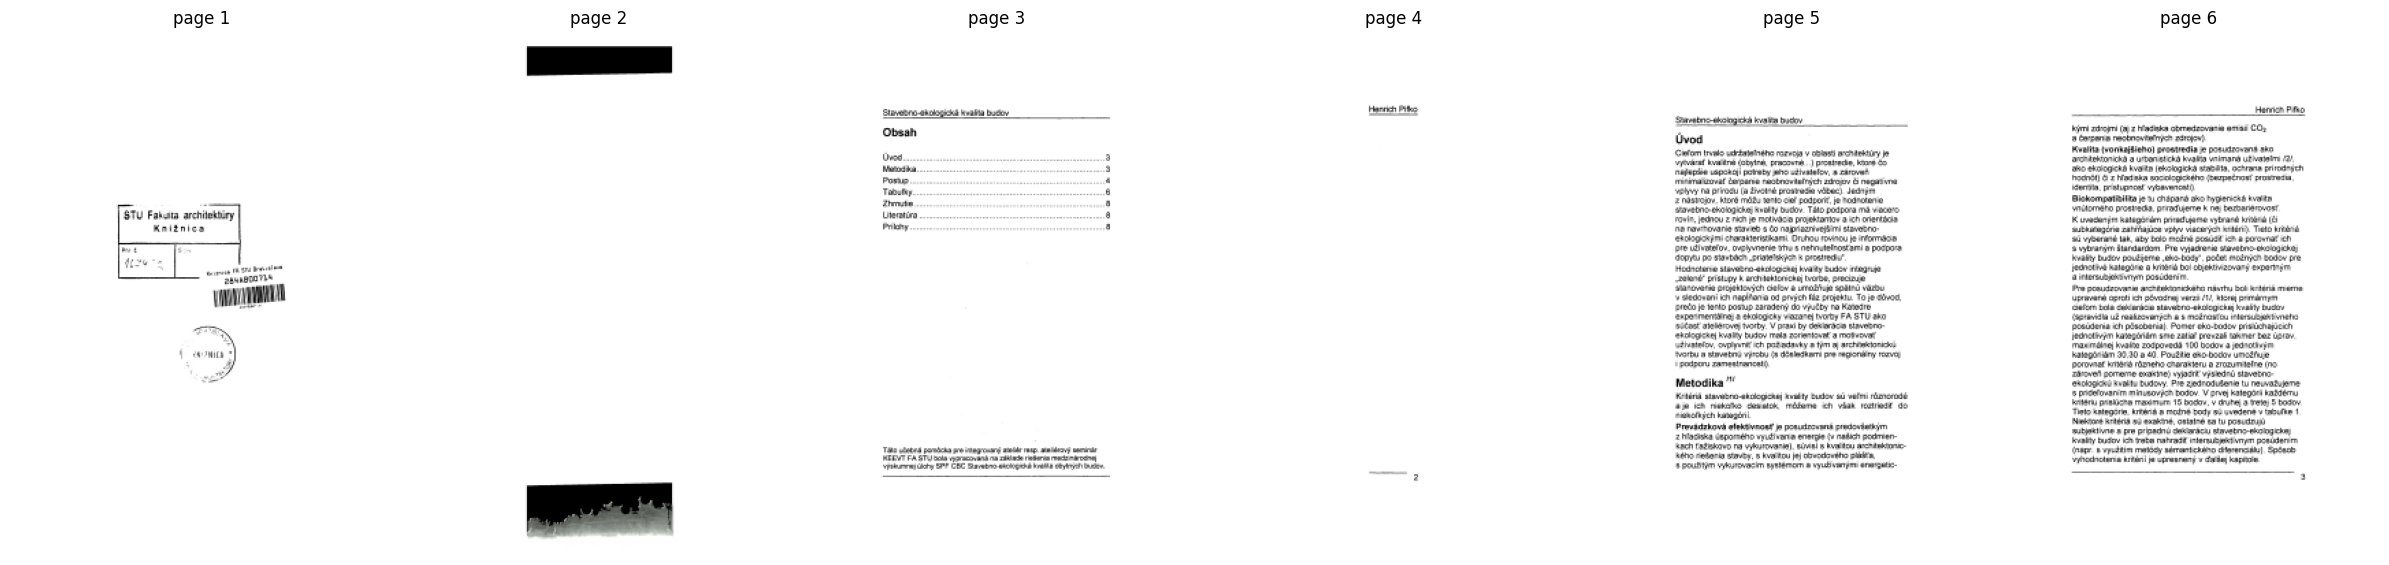

In [4]:
doc = pdfium.PdfDocument(str(pdf))
n_show = min(6, len(doc))
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 8))
for ax, i in zip(axes, range(n_show)):
    ax.imshow(doc[i].render(scale=0.5).to_pil(), cmap="gray")
    ax.set_title(f"page {i + 1}")
    ax.axis("off")
plt.tight_layout()

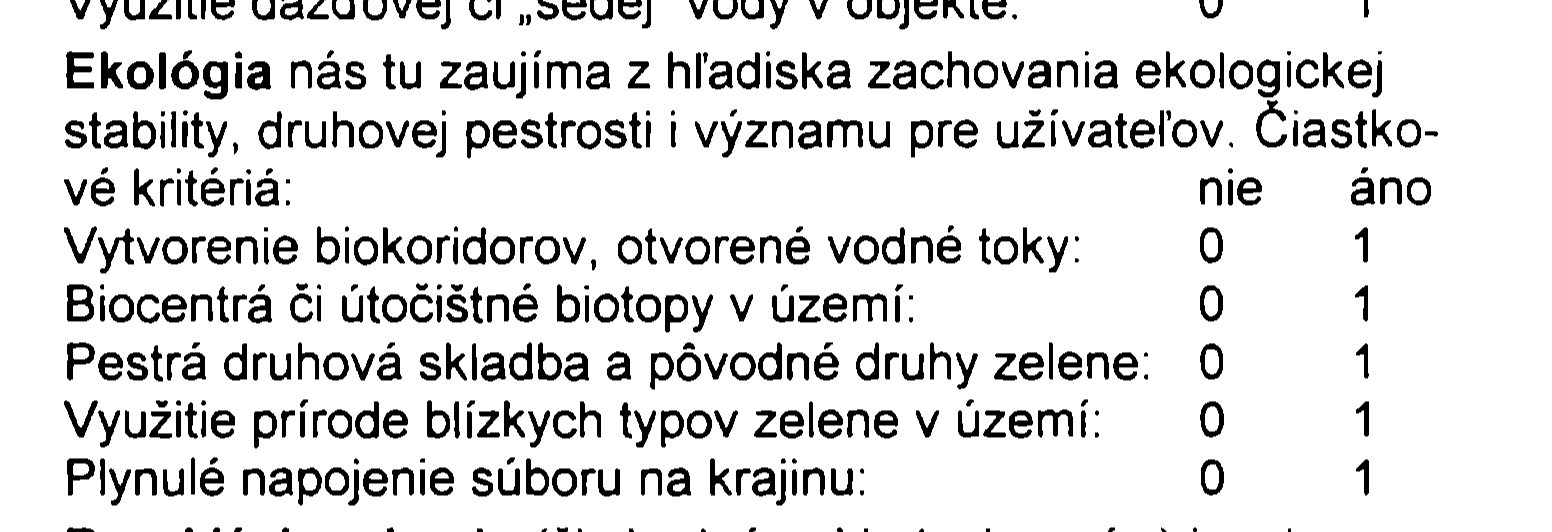

In [5]:
# zoom: render one page at full resolution and crop the centre
PAGE = 9
img = doc[PAGE].render(scale=300 / 72).to_pil()
w, h = img.size
img.crop((w // 6, h // 3, 5 * w // 6, h // 2))

## Compare with the legacy output

If the book was already digitized with the legacy engine (`output/<source>/`), put the
two PDFs side by side.

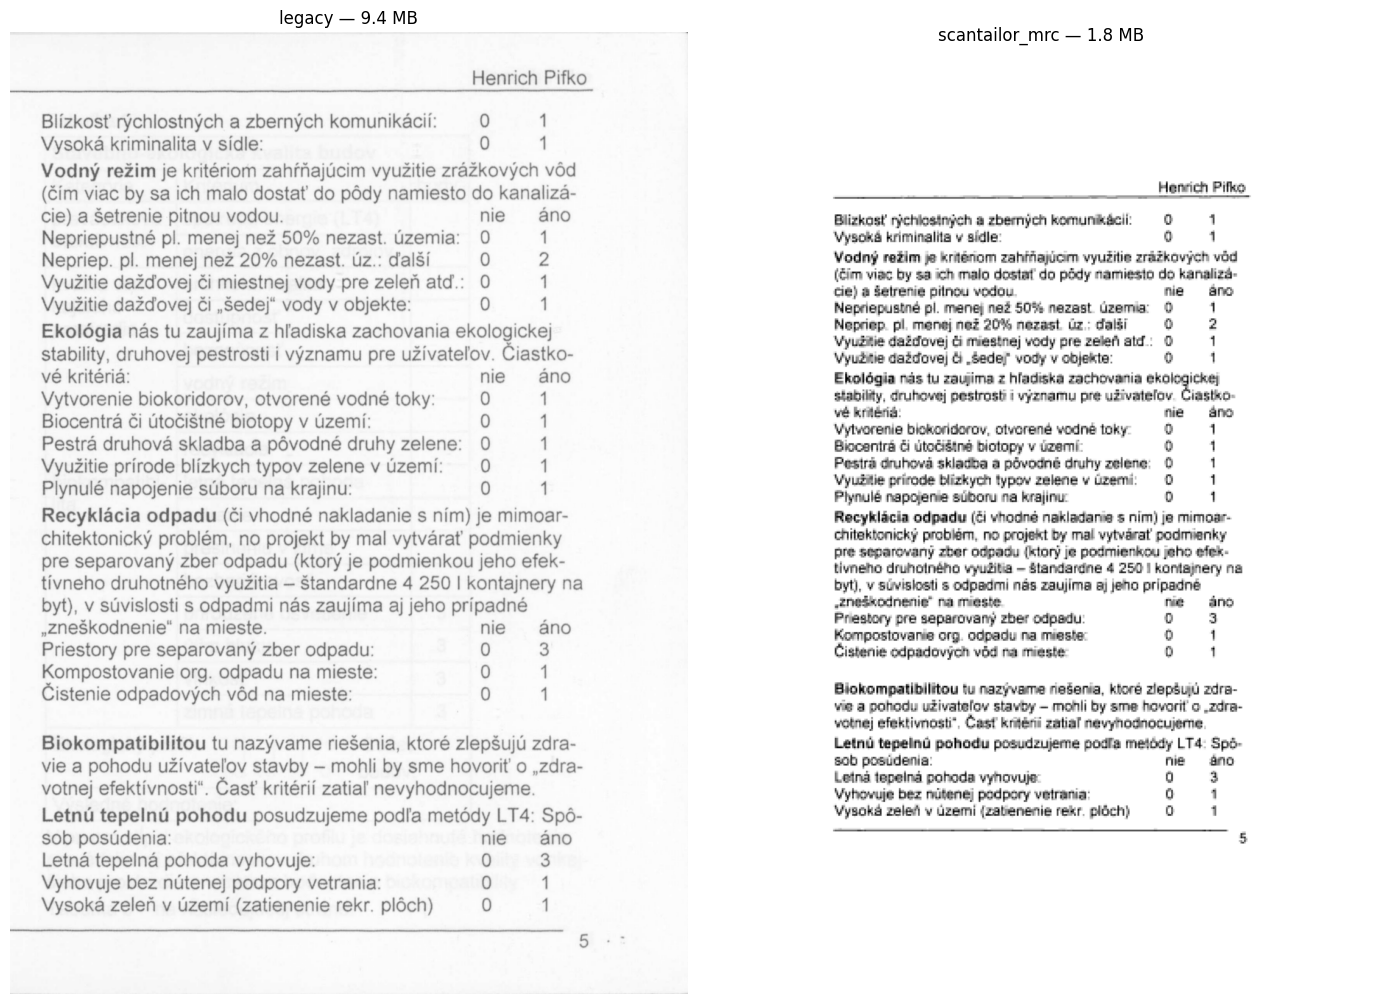

In [6]:
legacy_pdf = settings.output_dir / SOURCE / f"{SOURCE}_{BOOK_ID}.pdf"
if legacy_pdf.exists():
    legacy = pdfium.PdfDocument(str(legacy_pdf))
    page = min(9, len(legacy) - 1, len(doc) - 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 10))
    for ax, (d, title) in zip(
        axes,
        [(legacy, f"legacy — {legacy_pdf.stat().st_size / 1e6:.1f} MB"),
         (doc, f"scantailor_mrc — {pdf.stat().st_size / 1e6:.1f} MB")],
    ):
        ax.imshow(d[page].render(scale=0.7).to_pil(), cmap="gray")
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
else:
    print(f"no legacy PDF at {legacy_pdf} — nothing to compare")